Saved Excel: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\CDHW_Migration_Distance_LandOnly_Filtered_Hexagonal_AvgMigration.xlsx
Number of land hexagons: 1092


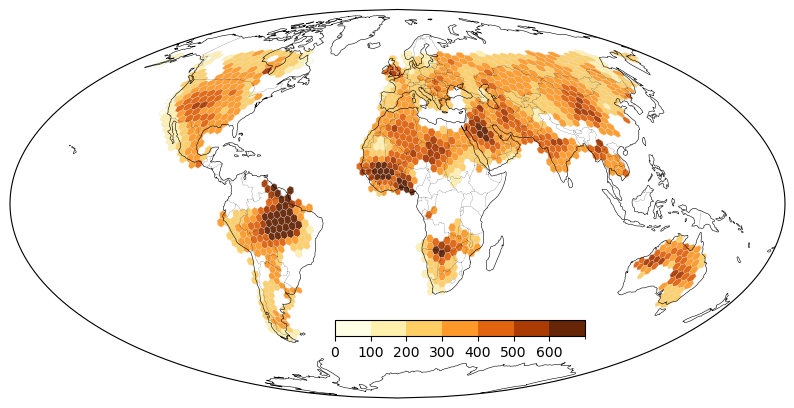

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.svg


In [3]:
import os
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Polygon
import h3
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Input and output files
tif_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\CDHW_Migration_Distance_LandOnly.tif"

land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

output_excel = tif_file.replace(
    ".tif",
    "_Filtered_Hexagonal_AvgMigration.xlsx"
)

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_CDHW.svg"

# Create output folder
os.makedirs(os.path.dirname(out_png), exist_ok=True)

# Hexagons to exclude
exclude_hex_ids = {
    "8258d7fffffffff",
    "8282d7fffffffff",
    "8258dffffffffff",
    "82828ffffffffff",
    "8282f7fffffffff",
    "828287fffffffff",
    "8282b7fffffffff",
    "8282affffffffff",
    "8282a7fffffffff",
    "82821ffffffffff",
    "828217fffffffff",
    "828207fffffffff",
    "828387fffffffff",
    "828237fffffffff",
    "8283affffffffff",
    "8283a7fffffffff",
    "82831ffffffffff",
    "8296effffffffff",
    "8283b7fffffffff",
    "82965ffffffffff",
    "828317fffffffff",
    "829657fffffffff",
    "82964ffffffffff",
    "828307fffffffff",
    "829647fffffffff"
}

# Set H3 resolution
H3_RESOLUTION = 2

# Read Natural Earth land polygons
land = gpd.read_file(land_path)

if land.crs is None:
    land = land.set_crs("EPSG:4326")
else:
    land = land.to_crs("EPSG:4326")

# Merge all land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

# Read migration-distance raster
with rasterio.open(tif_file) as src:

    raster_data = src.read(1).astype(float)
    nodata_value = src.nodata
    transform = src.transform

    rows, cols = np.indices(raster_data.shape)

    xs, ys = rasterio.transform.xy(
        transform,
        rows,
        cols,
        offset="center"
    )

# Convert raster coordinates to arrays
lon_grid = np.asarray(xs, dtype=float)
lat_grid = np.asarray(ys, dtype=float)

lon_flat = lon_grid.ravel()
lat_flat = lat_grid.ravel()
values_flat = raster_data.ravel()

# Remove NoData and invalid raster values
valid = np.isfinite(values_flat)

if nodata_value is not None:
    valid &= values_flat != nodata_value

lon_valid = lon_flat[valid]
lat_valid = lat_flat[valid]
values_valid = values_flat[valid]

# Restrict geographic domain
domain = (
    (lat_valid >= -66) &
    (lat_valid <= 60) &
    (lon_valid >= -170) &
    (lon_valid <= 170)
)

lon_valid = lon_valid[domain]
lat_valid = lat_valid[domain]
values_valid = values_valid[domain]

# Aggregate raster values into H3 cells
hex_data = {}

for lon, lat, value in zip(
    lon_valid,
    lat_valid,
    values_valid
):

    hex_id = h3.latlng_to_cell(
        lat,
        lon,
        H3_RESOLUTION
    )

    if hex_id in exclude_hex_ids:
        continue

    hex_data.setdefault(
        hex_id,
        []
    ).append(value)

# Calculate mean CDHW migration distance per hexagon
hex_avg_values = {
    hex_id: np.nanmean(values)
    for hex_id, values in hex_data.items()
}

# Convert H3 cells to polygons
records = []

for hex_id, avg_value in hex_avg_values.items():

    boundary = h3.cell_to_boundary(
        hex_id
    )

    polygon = Polygon(
        [
            (lng, lat)
            for lat, lng in boundary
        ]
    )

    centroid_lat, centroid_lon = h3.cell_to_latlng(
        hex_id
    )

    records.append({
        "hex_id": hex_id,
        "centroid_x": centroid_lon,
        "centroid_y": centroid_lat,
        "value": avg_value,
        "geometry": polygon
    })

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs="EPSG:4326"
)

# Keep only hexagons intersecting land
gdf = gdf[
    gdf.geometry.intersects(
        land_union
    )
].copy()

# Remove duplicate hexagons
gdf = gdf.drop_duplicates(
    subset="hex_id"
).reset_index(drop=True)

# Save processed hexagon data
gdf[
    [
        "hex_id",
        "centroid_x",
        "centroid_y",
        "value"
    ]
].to_excel(
    output_excel,
    index=False
)

print("Saved Excel:", output_excel)
print("Number of land hexagons:", len(gdf))

# Find maximum migration distance
max_value = gdf["value"].max()

# Define discrete CDHW migration-distance bins
base_bins = np.array(
    [0, 100, 200, 300, 400, 500, 600],
    dtype=float
)

upper_limit = max(
    700.0,
    np.ceil(max_value / 100.0) * 100.0
)

bins = np.append(
    base_bins,
    upper_limit
)

# Define colorbar tick labels
tick_labels = [
    "0",
    "100",
    "200",
    "300",
    "400",
    "500",
    "600"
]

# Create discrete YlOrBr colormap
custom_cmap = plt.get_cmap(
    "YlOrBr",
    len(bins) - 1
)

norm = mcolors.BoundaryNorm(
    bins,
    custom_cmap.N,
    clip=True
)

# Create transparent Mollweide figure
fig = plt.figure(
    figsize=(10, 8),
    facecolor="none"
)

ax = plt.axes(
    projection=ccrs.Mollweide(
        central_longitude=0
    )
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")
ax.set_global()

# Plot CDHW migration-distance hexagons
gdf.plot(
    column="value",
    cmap=custom_cmap,
    norm=norm,
    edgecolor="gainsboro",
    linewidth=0.20,
    alpha=0.95,
    ax=ax,
    transform=ccrs.PlateCarree()
)

# Draw coastlines and borders
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.4
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.3,
    linestyle=":"
)

# Create horizontal colorbar axis
colorbar_ax = fig.add_axes(
    [0.45, 0.33, 0.25, 0.02]
)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=norm
)

sm.set_array([])

# Add colorbar
cbar = fig.colorbar(
    sm,
    cax=colorbar_ax,
    orientation="horizontal"
)

# Set colorbar ticks and labels
cbar.set_ticks(
    base_bins
)

cbar.set_ticklabels(
    tick_labels
)

cbar.ax.tick_params(
    labelsize=10
)


# Save transparent high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

Saved Excel: D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\HW_Migration_Distance_LandOnly_Filtered_Hexagonal_HW_AvgMigration.xlsx
Number of land hexagons: 1092


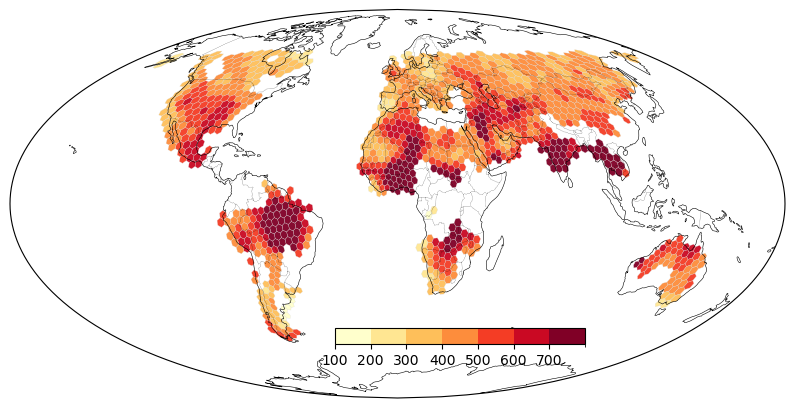

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.svg


In [4]:
import os
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Polygon
import h3
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Input and output paths
tif_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\HW_Migration_Distance_LandOnly.tif"

land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

output_excel = tif_file.replace(
    ".tif",
    "_Filtered_Hexagonal_HW_AvgMigration.xlsx"
)

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\heatwave\Hexagonal_HW.svg"

# Create output folder
os.makedirs(os.path.dirname(out_png), exist_ok=True)

# Hexagons to exclude
exclude_hex_ids = {
    "8258d7fffffffff",
    "8282d7fffffffff",
    "8258dffffffffff",
    "82828ffffffffff",
    "8282f7fffffffff",
    "828287fffffffff",
    "8282b7fffffffff",
    "8282affffffffff",
    "8282a7fffffffff",
    "82821ffffffffff",
    "828217fffffffff",
    "828207fffffffff",
    "828387fffffffff",
    "828237fffffffff",
    "8283affffffffff",
    "8283a7fffffffff",
    "82831ffffffffff",
    "8296effffffffff",
    "8283b7fffffffff",
    "82965ffffffffff",
    "828317fffffffff",
    "829657fffffffff",
    "82964ffffffffff",
    "828307fffffffff",
    "829647fffffffff"
}

# Set H3 resolution
H3_RESOLUTION = 2

# Read Natural Earth land polygons
land = gpd.read_file(land_path)

if land.crs is None:
    land = land.set_crs("EPSG:4326")
else:
    land = land.to_crs("EPSG:4326")

# Merge all land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

# Read raster data
with rasterio.open(tif_file) as src:

    raster_data = src.read(1).astype(float)
    nodata_value = src.nodata
    transform = src.transform

    rows, cols = np.indices(raster_data.shape)

    xs, ys = rasterio.transform.xy(
        transform,
        rows,
        cols,
        offset="center"
    )

# Convert coordinates to arrays
lon_grid = np.asarray(xs, dtype=float)
lat_grid = np.asarray(ys, dtype=float)

lon_flat = lon_grid.ravel()
lat_flat = lat_grid.ravel()
values_flat = raster_data.ravel()

# Remove NoData and invalid values
mask = np.isfinite(values_flat)

if nodata_value is not None:
    mask &= values_flat != nodata_value

lon_valid = lon_flat[mask]
lat_valid = lat_flat[mask]
values_valid = values_flat[mask]

# Restrict geographic domain
domain_mask = (
    (lat_valid >= -66) &
    (lat_valid <= 60) &
    (lon_valid >= -170) &
    (lon_valid <= 170)
)

lon_valid = lon_valid[domain_mask]
lat_valid = lat_valid[domain_mask]
values_valid = values_valid[domain_mask]

# Aggregate raster values into H3 cells
hex_data = {}

for lon, lat, value in zip(
    lon_valid,
    lat_valid,
    values_valid
):

    hex_id = h3.latlng_to_cell(
        lat,
        lon,
        H3_RESOLUTION
    )

    if hex_id not in exclude_hex_ids:
        hex_data.setdefault(
            hex_id,
            []
        ).append(value)

# Calculate mean migration distance per hexagon
hex_avg_values = {
    hex_id: np.nanmean(values)
    for hex_id, values in hex_data.items()
}

# Build hexagon polygons
records = []

for hex_id, avg_value in hex_avg_values.items():

    boundary = h3.cell_to_boundary(
        hex_id
    )

    polygon = Polygon(
        [
            (lng, lat)
            for lat, lng in boundary
        ]
    )

    centroid_lat, centroid_lon = h3.cell_to_latlng(
        hex_id
    )

    records.append({
        "hex_id": hex_id,
        "centroid_x": centroid_lon,
        "centroid_y": centroid_lat,
        "value": avg_value,
        "geometry": polygon
    })

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs="EPSG:4326"
)

# Keep only hexagons intersecting land
gdf = gdf[
    gdf.geometry.intersects(
        land_union
    )
].copy()

# Remove duplicate hexagons if any
gdf = gdf.drop_duplicates(
    subset="hex_id"
).reset_index(drop=True)

# Save hexagonal values to Excel
gdf[
    [
        "hex_id",
        "centroid_x",
        "centroid_y",
        "value"
    ]
].to_excel(
    output_excel,
    index=False
)

print("Saved Excel:", output_excel)
print("Number of land hexagons:", len(gdf))

# Find maximum migration distance
max_value = gdf["value"].max()

# Define discrete bins
base_bins = np.array(
    [100, 200, 300, 400, 500, 600, 700],
    dtype=float
)

upper_limit = max(
    800.0,
    np.ceil(max_value / 100.0) * 100.0
)

bins = np.append(
    base_bins,
    upper_limit
)

# Define colorbar labels
tick_labels = [
    "100",
    "200",
    "300",
    "400",
    "500",
    "600",
    "700"
]

# Keep values within display range
gdf = gdf[
    gdf["value"] >= bins[0]
].copy()

# Create discrete colormap
custom_cmap = plt.get_cmap(
    "YlOrRd",
    len(bins) - 1
)

norm = mcolors.BoundaryNorm(
    bins,
    custom_cmap.N,
    clip=True
)

# Create transparent Mollweide figure
fig = plt.figure(
    figsize=(10, 8),
    facecolor="none"
)

ax = plt.axes(
    projection=ccrs.Mollweide(
        central_longitude=0
    )
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

ax.set_global()

# Plot hexagons
gdf.plot(
    column="value",
    cmap=custom_cmap,
    norm=norm,
    edgecolor="gainsboro",
    linewidth=0.20,
    alpha=0.95,
    ax=ax,
    transform=ccrs.PlateCarree()
)

# Draw coastlines and borders
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.4
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.3,
    linestyle=":"
)

# Add horizontal colorbar
colorbar_ax = fig.add_axes(
    [0.45, 0.32, 0.25, 0.02]
)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=colorbar_ax,
    orientation="horizontal"
)

# Set colorbar ticks
cbar.set_ticks(
    base_bins
)

cbar.set_ticklabels(
    tick_labels
)

cbar.ax.tick_params(
    labelsize=10
)

# Save transparent high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

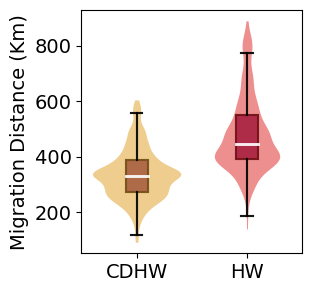

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.png
Saved vector PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.pdf
Saved vector SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.svg


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\CDHW_HW_Migration_Distance_LandOnly_Hexagonal_Merged_With_Aridity.xlsx"
df = pd.read_excel(file_path)

# Filter data for "Humid" category
df_filtered = df[df["Aridity_Class"] == "Humid"]

# Function to remove outliers using IQR
def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Extract values and remove NaN, infinite values, and outliers
cdhw_distance = df_filtered["CDHW_value"].replace([np.inf, -np.inf], np.nan).dropna()
hw_distance = df_filtered["HW_value"].replace([np.inf, -np.inf], np.nan).dropna()

cdhw_distance = remove_outliers(cdhw_distance)
hw_distance = remove_outliers(hw_distance)

# Check if data is empty after cleaning
if cdhw_distance.empty or hw_distance.empty:
    raise ValueError("After cleaning, data is empty. Check the source file for valid numerical values.")

# Create a combined DataFrame for violin and box plots
df_violin = pd.DataFrame({
    "Distance": np.concatenate([cdhw_distance, hw_distance]),
    "Category": ["CDHW"] * len(cdhw_distance) + ["HW"] * len(hw_distance)
})

# Define colors for categories
violin_colors = {"CDHW": "orange", "HW": "red"}

# Create the figure
plt.figure(figsize=(3.2, 3))

# Violin plot
ax = sns.violinplot(
    x="Category",
    y="Distance",
    data=df_violin,
    palette=violin_colors,
    inner=None,
    linewidth=0,
    width=0.8,
    cut=0
)

# Modify transparency of the violin plots
for violin in ax.collections:
    violin.set_alpha(0.5)

# Overlay first boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "orange",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Overlay second boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "indigo",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Labels
plt.xlabel("")
plt.ylabel("Migration Distance (Km)", fontsize=14)

# Tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Adjust spacing
plt.tight_layout(pad=1)

# Output files
out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Humid.svg"

# Save PNG
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Display the plot
plt.show()

# Print confirmation
print("Saved PNG:", out_png)
print("Saved vector PDF:", out_pdf)
print("Saved vector SVG:", out_svg)

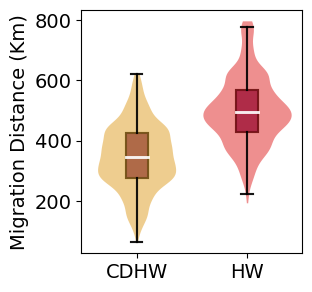

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.png
Saved vector PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.pdf
Saved vector SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.svg
Arid violin plot completed.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\CDHW_HW_Migration_Distance_LandOnly_Hexagonal_Merged_With_Aridity.xlsx"
df = pd.read_excel(file_path)

# Filter data for "Arid" category
df_filtered = df[df["Aridity_Class"] == "Arid"]

# Function to remove outliers using IQR
def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Extract values and remove NaN, infinite values, and outliers
cdhw_distance = df_filtered["CDHW_value"].replace([np.inf, -np.inf], np.nan).dropna()
hw_distance = df_filtered["HW_value"].replace([np.inf, -np.inf], np.nan).dropna()

cdhw_distance = remove_outliers(cdhw_distance)
hw_distance = remove_outliers(hw_distance)

# Check if data is empty after cleaning
if cdhw_distance.empty or hw_distance.empty:
    raise ValueError("After cleaning, data is empty. Check the source file for valid numerical values.")

# Create combined DataFrame
df_violin = pd.DataFrame({
    "Distance": np.concatenate([cdhw_distance, hw_distance]),
    "Category": ["CDHW"] * len(cdhw_distance) + ["HW"] * len(hw_distance)
})

# Define colors
violin_colors = {
    "CDHW": "orange",
    "HW": "red"
}

# Create figure
plt.figure(figsize=(3.2, 3))

# Violin plot
ax = sns.violinplot(
    x="Category",
    y="Distance",
    data=df_violin,
    palette=violin_colors,
    inner=None,
    linewidth=0,
    width=0.8,
    cut=0
)

# Set violin transparency
for violin in ax.collections:
    violin.set_alpha(0.5)

# Overlay first boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "orange",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Overlay second boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "indigo",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Labels
plt.xlabel("")
plt.ylabel("Migration Distance (Km)", fontsize=14)

# Tick font sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Adjust padding
plt.tight_layout(pad=1)

# Output files
out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Arid.svg"

# Save PNG
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Display plot
plt.show()

# Print confirmation
print("Saved PNG:", out_png)
print("Saved vector PDF:", out_pdf)
print("Saved vector SVG:", out_svg)
print("Arid violin plot completed.")

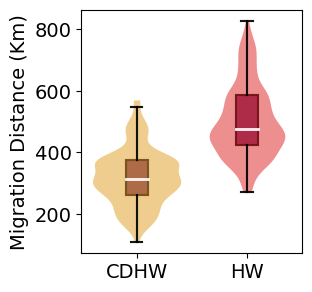

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.png
Saved vector PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.pdf
Saved vector SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.svg
Semi-Arid violin plot without outliers completed.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ_Total_HW\CDHW_HW_Migration_Distance_LandOnly_Hexagonal_Merged_With_Aridity.xlsx"
df = pd.read_excel(file_path)

# Filter data for "Semi-Arid" category
df_filtered = df[df["Aridity_Class"] == "Semi-Arid"]

# Remove outliers using IQR
def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Extract values and remove NaN, infinite values, and outliers
cdhw_distance = df_filtered["CDHW_value"].replace([np.inf, -np.inf], np.nan).dropna()
hw_distance = df_filtered["HW_value"].replace([np.inf, -np.inf], np.nan).dropna()

cdhw_distance = remove_outliers(cdhw_distance)
hw_distance = remove_outliers(hw_distance)

# Check if data is empty after cleaning
if cdhw_distance.empty or hw_distance.empty:
    raise ValueError("After cleaning, data is empty. Check the source file for valid numerical values.")

# Create combined DataFrame
df_violin = pd.DataFrame({
    "Distance": np.concatenate([cdhw_distance, hw_distance]),
    "Category": ["CDHW"] * len(cdhw_distance) + ["HW"] * len(hw_distance)
})

# Define violin colors
violin_colors = {
    "CDHW": "orange",
    "HW": "red"
}

# Create figure
plt.figure(figsize=(3.2, 3))

# Violin plot
ax = sns.violinplot(
    x="Category",
    y="Distance",
    data=df_violin,
    palette=violin_colors,
    inner=None,
    linewidth=0,
    width=0.8,
    cut=0
)

# Set violin transparency
for violin in ax.collections:
    violin.set_alpha(0.5)

# Overlay first boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "orange",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Overlay second boxplot
sns.boxplot(
    x="Category",
    y="Distance",
    data=df_violin,
    width=0.2,
    showcaps=True,
    boxprops={
        "facecolor": "indigo",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "alpha": 0.7
    },
    medianprops={
        "color": "white",
        "linewidth": 2,
        "alpha": 0.7
    },
    flierprops={
        "marker": "o",
        "alpha": 0
    },
    zorder=2
)

# Axis labels
plt.xlabel("")
plt.ylabel("Migration Distance (Km)", fontsize=14)

# Tick labels
plt.xticks(fontsize=14)
plt.yticks([200, 400, 600, 800], fontsize=14)

# Adjust layout
plt.tight_layout(pad=1)

# Output files
out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Violin_Box_CDHW_HW_Semi-Arid_NoOutliers.svg"

# Save PNG
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Display the plot
plt.show()

# Print confirmation
print("Saved PNG:", out_png)
print("Saved vector PDF:", out_pdf)
print("Saved vector SVG:", out_svg)
print("Semi-Arid violin plot without outliers completed.")